# 🧪 Feature Engineering & EDA: 2026 Regulations

With the new 2026 Formula 1 regulations, we are analyzing the raw performance indicators from the race weekend: **Free Practice Pace** and **Qualifying Gaps**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load 2026 Data
df = pd.read_parquet('data/f1_2026_dataset.parquet')
df_aus = df[df['EventName'] == 'Australian Grand Prix'].copy()
print(f"Loaded Australian GP Data: {len(df_aus)} drivers")

Loaded Australian GP Data: 22 drivers


## 1. Free Practice Pace Analysis

Who had the best raw speed (Short Run) and race simulation (Long Run) during practice?

/var/folders/73/nl09tr_d4j9gbpb_q6hb0c3m0000gn/T/ipykernel_83249/437757087.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_short, x='Driver', y='FP_ShortRunPace', ax=axes[0], palette='viridis')
/var/folders/73/nl09tr_d4j9gbpb_q6hb0c3m0000gn/T/ipykernel_83249/437757087.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_long, x='Driver', y='FP_LongRunPace', ax=axes[1], palette='magma')


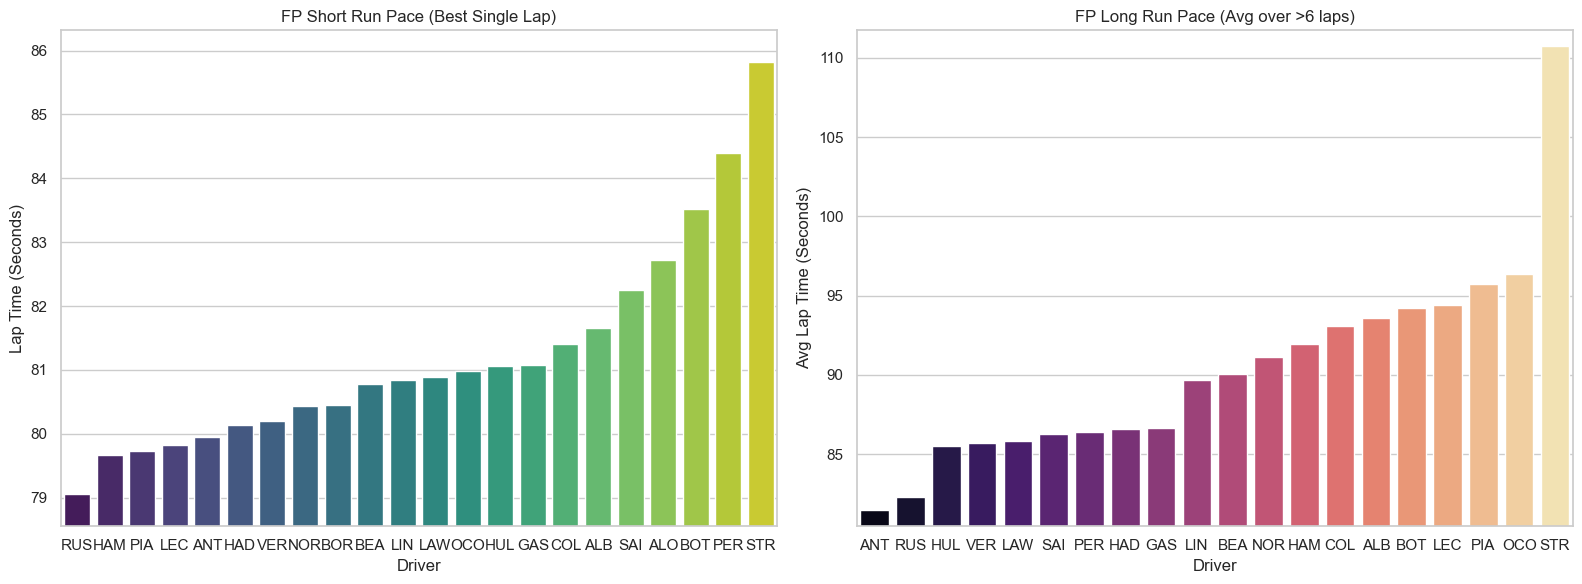

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Short Run Pace
df_short = df_aus.dropna(subset=['FP_ShortRunPace']).sort_values('FP_ShortRunPace')
sns.barplot(data=df_short, x='Driver', y='FP_ShortRunPace', ax=axes[0], palette='viridis')
axes[0].set_ylim(df_short['FP_ShortRunPace'].min() - 0.5, df_short['FP_ShortRunPace'].max() + 0.5)
axes[0].set_title('FP Short Run Pace (Best Single Lap)')
axes[0].set_ylabel('Lap Time (Seconds)')

# Long Run Pace
df_long = df_aus.dropna(subset=['FP_LongRunPace']).sort_values('FP_LongRunPace')
sns.barplot(data=df_long, x='Driver', y='FP_LongRunPace', ax=axes[1], palette='magma')
axes[1].set_ylim(df_long['FP_LongRunPace'].min() - 1.0, df_long['FP_LongRunPace'].max() + 1.0)
axes[1].set_title('FP Long Run Pace (Avg over >6 laps)')
axes[1].set_ylabel('Avg Lap Time (Seconds)')

plt.tight_layout()
plt.show()

## 2. Qualifying Gap vs Race Result

Does Qualifying performance dictate the race winner in 2026?

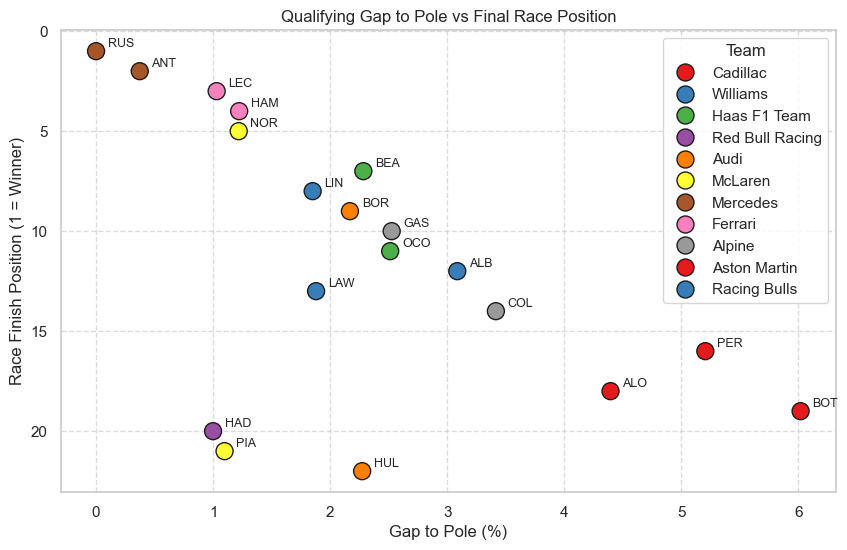

In [3]:
df_quali = df_aus.dropna(subset=['GapToPole', 'FinishPosition'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_quali, x='GapToPole', y='FinishPosition', hue='Team', s=150, palette='Set1', edgecolor='k')

for i, row in df_quali.iterrows():
    plt.annotate(row['Driver'], (row['GapToPole'] + 0.1, row['FinishPosition'] - 0.2), fontsize=9)

plt.title('Qualifying Gap to Pole vs Final Race Position')
plt.xlabel('Gap to Pole (%)')
plt.ylabel('Race Finish Position (1 = Winner)')
plt.gca().invert_yaxis()  # Best position at the top
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 3. Feature Correlation
Let's check which feature correlates best with `FinishPosition` (lower is better, so positive correlation with PoleGap/Pace means slower pace = worse position).

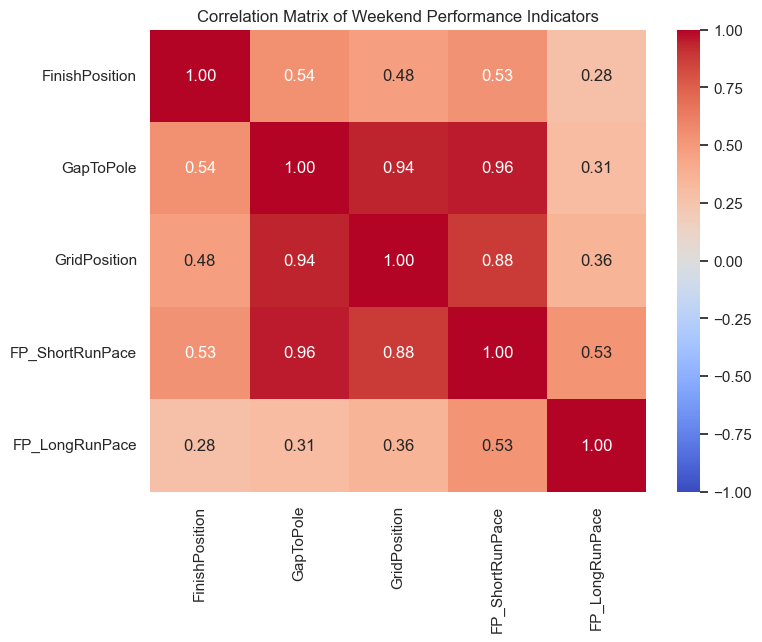

In [4]:
corr_features = ['Wait...']
features_to_corr = ['FinishPosition', 'GapToPole', 'GridPosition', 'FP_ShortRunPace', 'FP_LongRunPace']
corr_matrix = df_aus[features_to_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Weekend Performance Indicators')
plt.show()